In [1]:
import pandas as pd

pd.set_option('display.max_columns', 50)

df = pd.read_csv('./data/data_clean.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               2556 non-null   str    
 1   age                  2556 non-null   int64  
 2   city                 2556 non-null   str    
 3   status               2556 non-null   str    
 4   profession           1883 non-null   str    
 5   academic_pressure    502 non-null    float64
 6   work_pressure        2054 non-null   float64
 7   cgpa                 502 non-null    float64
 8   study_satisfaction   502 non-null    float64
 9   job_satisfaction     2054 non-null   float64
 10  sleep_duration       2556 non-null   int64  
 11  dietary_habits       2556 non-null   str    
 12  degree               2556 non-null   str    
 13  suicidal_thoughts    2556 non-null   int64  
 14  workstudy_hours      2556 non-null   int64  
 15  financial_stress     2556 non-null   int64  
 16 

In [3]:
from sklearn.model_selection import train_test_split

initial_set, newcomer_set = train_test_split(df, test_size=.15, random_state=True, shuffle=True)
print('Initial Set:', len(initial_set))
print('Newcomer Set:', len(newcomer_set))

Initial Set: 2172
Newcomer Set: 384


In [4]:
from modeling.agglomerative_clustering import AggloGroupModel
from modeling.baseline import BaselineGroupModel
from modeling.evaluate import Evaluator

In [5]:
base_model = BaselineGroupModel()
base_model.fit(initial_set)
base_groups = base_model.predict(initial_set)
initial_set['base_group_assignment'] = base_groups.astype(str)
base_eval = Evaluator(base_model)

In [6]:
initial_set.base_group_assignment.describe()

count     2172
unique     181
top         45
freq        12
Name: base_group_assignment, dtype: object

In [7]:
initial_set.base_group_assignment.value_counts()

base_group_assignment
45     12
155    12
91     12
175    12
107    12
       ..
52     12
176    12
14     12
19     12
65     12
Name: count, Length: 181, dtype: int64

In [8]:
print(base_eval.report(initial_set))


Metrics report:
  Groups:     181
  Sizes:      min=12  max=12  mean=12.0  std=0.0  cv=0.000
  WCSS:       total=471460.29 mean= 2604.75
  Silhouette: -0.2577  (metric=euclidean)


In [9]:
agglo_model = AggloGroupModel()
agglo_model.fit(initial_set)
agglo_groups = agglo_model.predict(initial_set)
initial_set['agglo_group_assignment'] = agglo_groups.astype(str)
agglo_eval = Evaluator(agglo_model)

In [10]:
initial_set.agglo_group_assignment.describe()

count     2172
unique     268
top         71
freq        12
Name: agglo_group_assignment, dtype: object

<Axes: xlabel='count'>

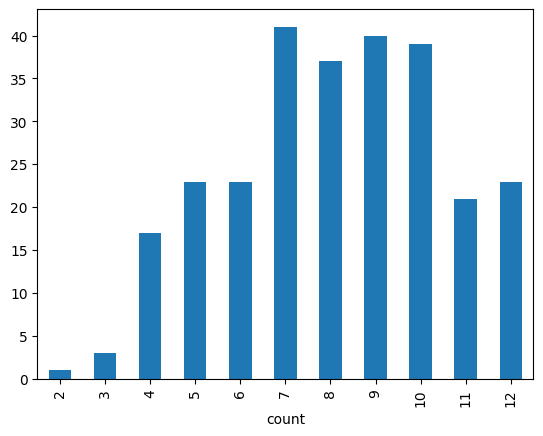

In [14]:
initial_set.agglo_group_assignment.value_counts().value_counts().sort_index().plot.bar()

In [12]:
print(agglo_eval.report(initial_set))

Metrics report:
  Groups:     268
  Sizes:      min=2  max=12  mean=8.1  std=2.3  cv=0.289
  WCSS:       total=35153.96 mean= 131.17
  Silhouette: 0.1237  (metric=euclidean)


In [15]:
agglo_eval.feature_homogeneity(initial_set)

,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,suicidal_thoughts,workstudy_hours,financial_stress,family_history,depression,pressure,satisfaction,gender_enc,is_professional,dietary_enc,education_level,city_lat,city_lon,stress_index,wellbeing_score,worklife_balance,high_risk
0,42.777778,NaN,1.666667,NaN,NaN,3.444444,2.444444,0.222222,4.000000,4.333333,0.444444,0.0,1.666667,3.444444,0.444444,1.0,0.777778,0.888889,19.199532,73.294415,2.851852,2.222222,0.845679,0.111111
1,35.428571,NaN,2.571429,NaN,NaN,3.428571,2.571429,0.714286,9.857143,1.571429,0.428571,0.0,2.571429,3.428571,0.428571,1.0,1.428571,1.142857,21.837909,71.976322,2.190476,2.476190,0.607143,0.000000
2,40.833333,NaN,2.416667,NaN,NaN,3.000000,2.666667,0.583333,2.333333,2.916667,0.083333,0.0,2.416667,3.000000,0.500000,1.0,1.333333,1.333333,15.626157,79.533596,2.555556,2.333333,0.916667,0.083333
3,45.000000,NaN,2.166667,NaN,NaN,2.000000,2.333333,0.166667,1.500000,2.833333,0.333333,0.0,2.166667,2.000000,0.500000,1.0,1.333333,1.833333,24.090985,86.743710,2.555556,1.888889,0.953704,0.166667
4,19.400000,NaN,4.200000,NaN,NaN,1.800000,2.300000,0.600000,2.300000,2.700000,0.600000,0.9,4.200000,1.800000,0.500000,1.0,1.100000,0.200000,25.407920,81.002689,3.200000,1.733333,0.844444,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,19.285714,3.714286,NaN,8.001429,2.857143,NaN,3.428571,0.428571,8.285714,2.285714,0.428571,1.0,3.714286,2.857143,0.857143,0.0,0.285714,0.142857,22.556897,72.449861,2.523810,2.190476,0.865079,0.000000
264,42.666667,NaN,3.444444,NaN,NaN,4.000000,2.111111,0.222222,2.888889,4.222222,0.777778,0.0,3.444444,4.000000,0.444444,1.0,0.666667,1.444444,25.518099,84.418227,3.518519,2.259259,0.842593,0.555556
265,37.100000,NaN,1.300000,NaN,NaN,1.800000,2.300000,0.800000,7.000000,2.300000,0.600000,0.0,1.300000,1.800000,0.400000,1.0,0.800000,1.400000,19.527778,73.311144,2.100000,1.633333,0.686111,0.000000
266,35.000000,NaN,1.333333,NaN,NaN,4.166667,1.666667,0.333333,6.500000,4.000000,0.666667,0.0,1.333333,4.166667,0.166667,1.0,2.000000,1.666667,20.398684,73.112064,2.888889,2.611111,0.583333,0.333333


In [16]:
agglo_model.print_clusters(max_rows=12)

── Cluster 0  (9 members) ──────────────────────────────
      gender  age         city                status              profession  academic_pressure  work_pressure  cgpa  study_satisfaction  job_satisfaction  sleep_duration dietary_habits    degree  suicidal_thoughts  workstudy_hours  financial_stress  family_history  depression  pressure  satisfaction pressure_source sleep_duration_raw  gender_enc  is_professional  dietary_enc  education_level profession_category   city_lat   city_lon  stress_index  wellbeing_score age_group  worklife_balance  high_risk cgpa_band base_group_assignment
2074    Male   42  Vasai-Virar  Working Professional              Pharmacist                NaN            3.0   NaN                 NaN               4.0               2        Healthy      MBBS                  0                5                 4               0           0       3.0           4.0            work          5-6 hours           1                1            2                1        

In [20]:
initial_set.loc[2226]

gender                                  Female
age                                         19
city                                  Srinagar
status                    Working Professional
profession                                 NaN
academic_pressure                          NaN
work_pressure                              1.0
cgpa                                       NaN
study_satisfaction                         NaN
job_satisfaction                           5.0
sleep_duration                               2
dietary_habits                       Unhealthy
degree                                Class 12
suicidal_thoughts                            1
workstudy_hours                              6
financial_stress                             3
family_history                               0
depression                                   0
pressure                                   1.0
satisfaction                               5.0
pressure_source                           work
sleep_duratio